In [1]:
try:
    import secml
    import foolbox
    import sklearn
except Exception:
    %pip install 'secml[pytorch]' foolbox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 464.0/464.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.6/190.6 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.5 MB/s eta 0:00:00


# Exercise 1

Complete the following tasks using SecML

Create an SVM with scikit-learn (use SVC, leave the default parameters) and wrap it with the scikit-learn SecML wrapper seen during the course.

In [2]:
from sklearn.svm import SVC
from secml.ml.classifiers import CClassifierSkLearn

svc = SVC()
clf = CClassifierSkLearn(sklearn_model=svc)

2023-12-20 09:28:57,927 - secml.settings - INFO - New `SECML_HOME_DIR` created: /root/secml-data
2023-12-20 09:28:57,927 - secml.settings - INFO - New `SECML_HOME_DIR` created: /root/secml-data


INFO:secml.settings:New `SECML_HOME_DIR` created: /root/secml-data


2023-12-20 09:28:57,937 - secml.settings - INFO - Default configuration file copied to: /root/secml-data/secml.conf
2023-12-20 09:28:57,937 - secml.settings - INFO - Default configuration file copied to: /root/secml-data/secml.conf


INFO:secml.settings:Default configuration file copied to: /root/secml-data/secml.conf


2023-12-20 09:28:57,955 - secml.settings - INFO - New `SECML_DS_DIR` created: /root/secml-data/datasets
2023-12-20 09:28:57,955 - secml.settings - INFO - New `SECML_DS_DIR` created: /root/secml-data/datasets


...

INFO:secml.settings:New `SECML_EXP_DIR` created: /root/secml-data/experiments


2023-12-20 09:28:58,004 - secml.settings - INFO - New `SECML_LOGS_DIR` created: /root/secml-data/logs
2023-12-20 09:28:58,004 - secml.settings - INFO - New `SECML_LOGS_DIR` created: /root/secml-data/logs


INFO:secml.settings:New `SECML_LOGS_DIR` created: /root/secml-data/logs


2023-12-20 09:28:58,015 - secml.settings - INFO - New `SECML_PYTORCH_DIR` created: /root/secml-data/pytorch-data
2023-12-20 09:28:58,015 - secml.settings - INFO - New `SECML_PYTORCH_DIR` created: /root/secml-data/pytorch-data


INFO:secml.settings:New `SECML_PYTORCH_DIR` created: /root/secml-data/pytorch-data


Create a dataset consisting of 500 samples of 2D points from two clusters (CDLRandomBlobs), whose centers are located in (-2, 2) and (2,2) with standard deviation = 0.5. Normalize the dataset between 0 and 1 (CNormalizerMinMax).

In [4]:
from secml.data.loader import CDLRandomBlobs
from secml.ml.features.normalization import CNormalizerMinMax

n_samples = 500
centers = [(-2, 2), (2, 2)]
cluster_std = 0.5

# Load dataset
dataset = CDLRandomBlobs(n_samples=n_samples, centers=centers, cluster_std=cluster_std, random_state=0).load()

# Normalize samples between 0 and 1
dataset.X = CNormalizerMinMax().fit_transform(dataset.X)

Divide the data with the SecML splitter (CTrainTestSplit), using 400 samples per il training e 100 per il test.

In [5]:
from secml.data.splitter import CTrainTestSplit

# Split in training and test
splitter = CTrainTestSplit(train_size=400, random_state=0)
tr, ts = splitter.split(dataset)

Fit the classifier on the training data.

In [6]:
clf.fit(tr.X, tr.Y)

CClassifierSkLearn{'sklearn_model': SVC(), 'classes': CArray(2,)(dense: [0 1]), 'n_features': 2, 'preprocess': None, 'n_jobs': 1}

Compute the accuracy on the test set using the CMetricAccuracy object.

In [7]:
from secml.ml.peval.metrics import CMetricAccuracy

# Compute predictions on a test set
y_pred = clf.predict(ts.X)

# Evaluate accuracy of the classifier
metric = CMetricAccuracy()
acc = metric.performance_score(y_true=ts.Y, y_pred=y_pred)

print("Accuracy on test set: {:.2%}".format(acc))

Accuracy on test set: 100.00%


Plot the learned decision function using the ad-hoc method of the CFigure class.

Text(0.5, 1.0, 'Decision function of the classifier')

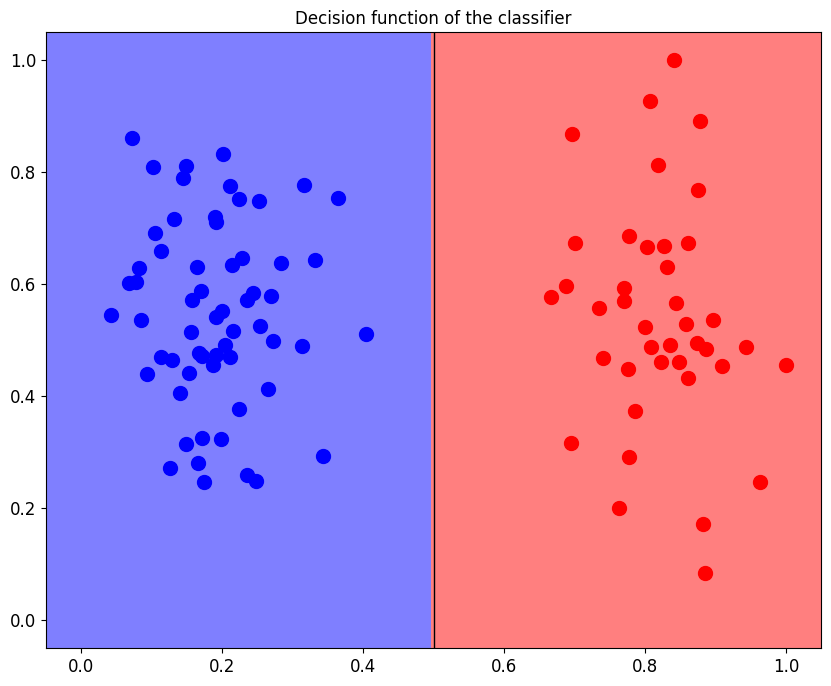

In [8]:
from secml.figure import CFigure
# Only required for visualization in notebooks
%matplotlib inline

# Let's plot the decision function learned on the dataset
fig = CFigure(width=10, height=8, markersize=10)
fig.sp.plot_ds(ts)
fig.sp.plot_decision_regions(clf, plot_background=True)
fig.sp.grid(grid_on=False)
fig.sp.title("Decision function of the classifier")

# Exercise 2

We provide you the code for training a simple model on 2D data. Execute the cell to create and fit the model.

Accuracy is 1.0


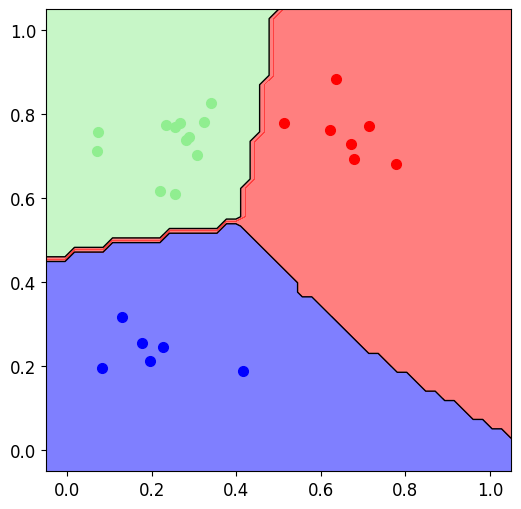

In [9]:
%matplotlib inline
import torch
torch.manual_seed(111)
from torch.nn.functional import relu, softmax
from torch.optim import SGD
from secml.ml.classifiers import CClassifierPyTorch
from secml.ml.features import CNormalizerMinMax
from secml.data.splitter import CTrainTestSplit
from secml.data.loader import CDLRandomBlobs
from secml.ml.features import CNormalizerMinMax
from secml.figure import CFigure
from secml.ml.peval.metrics import CMetricAccuracy

class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.lin1 = torch.nn.Linear(2, 50)
        self.lin2 = torch.nn.Linear(50, 50)
        self.lin3 = torch.nn.Linear(50, 3)

    def forward(self, x):
        x = relu(self.lin1(x))
        x = relu(self.lin2(x))
        y = self.lin3(x)
        return y

net = Net()
optimizer = SGD(net.parameters(), lr=0.01, momentum=0.9)
loss_function = torch.nn.CrossEntropyLoss()
from secml.ml.classifiers import CClassifierPyTorch
clf = CClassifierPyTorch(model=net,
                         loss=loss_function,
                         optimizer=optimizer,
                         epochs=30,
                         batch_size=32,
                         random_state=31)


dataset = CDLRandomBlobs(n_features=2,
                         centers=[[0,0], [1,1], [0,1]],
                         cluster_std=0.2,
                         n_samples=500,
                         random_state=111).load()

dataset.X = CNormalizerMinMax().fit_transform(dataset.X)
splitter = CTrainTestSplit(train_size=475, test_size=25, random_state=8)
tr, ts = splitter.split(dataset)

clf.fit(tr.X, tr.Y)

print(f"Accuracy is {CMetricAccuracy().performance_score(clf.predict(ts.X), ts.Y)}")
fig = CFigure()
fig.sp.plot_ds(ts)
fig.sp.plot_decision_regions(clf, n_grid_points=50)

Compute a security evaluation curve of the trained model using the corresponding SecML object (CSecEval) as shown in class, with the following setup.

* Use the CFoolboxPGDLInf attack from the SecML library, with 5 iterations and 0.05 as absolute step size, no random start, lower bound 0 and upper bound 1;

* Use at least 5 values for the perturbation budget epsilon.
Since it is an L-inf attack and the domain is bounded between 0 and 1, which is the maximum perturbation norm that the attack can reach?



Original x: CArray([[0.713148 0.772556]]) label:  1
Final x:    CArray([[0.013172 0.907433]]) label:  2
Number of classifier gradient evaluations: 3


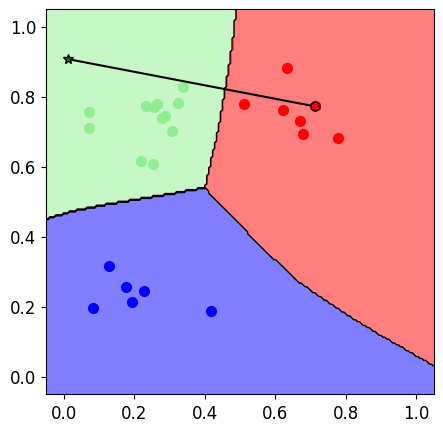

In [10]:
# complete here
x0, y0 = ts[5, :].X, ts[5, :].Y  # Initial sample--X is location, Y is classification

noise_type = 'l2'  # Type of perturbation 'l1' or 'l2'
dmax = 1  # Maximum perturbation
lb, ub = 0, 1  # Bounds of the attack space. Can be set to `None` for unbounded
y_target = None  # Move until the model gets any wrong answer

# Should be chosen depending on the optimization problem
solver_params = {
    'eta': 0.3,
    'eta_min': 0.1,
    'eta_max': None,
    'max_iter': 5,
    'eps': 0.05
}

from secml.adv.attacks.evasion import CAttackEvasionPGDLS
pgd_ls_attack = CAttackEvasionPGDLS(
    classifier=clf,
    double_init_ds=tr,
    double_init=False,
    distance=noise_type,
    dmax=dmax,
    lb=lb, ub=ub,
    solver_params=solver_params,
    y_target=y_target)

# Run the evasion attack on x0
y_pred_pgdls, _, adv_ds_pgdls, _ = pgd_ls_attack.run(x0, y0)

print("Original x:", x0, "label: ", y0.item())
print("Final x:   ", adv_ds_pgdls.X, "label: ", y_pred_pgdls.item(), )

print("Number of classifier gradient evaluations: {:}"
      "".format(pgd_ls_attack.grad_eval))

fig = CFigure(width=5, height=5)
fig.sp.plot_decision_regions(clf, n_grid_points=200)
fig.sp.plot_ds(ts)
fig.sp.grid(grid_on=False)
fig.sp.plot_path(x0.append(adv_ds_pgdls.X, axis=0))
fig.show()

Plot the security evaluation curve using the ad-hoc method of the CFigure class.

Running security evaluation...


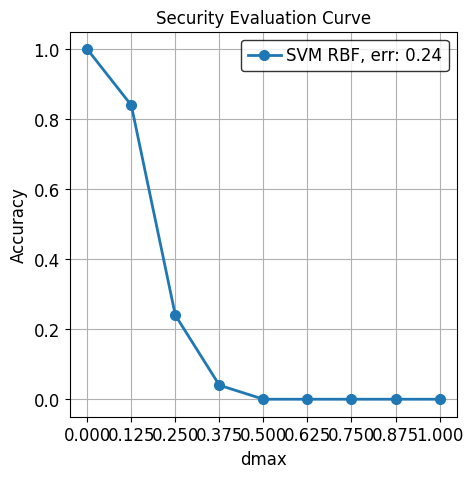

In [11]:
# complete here
# Perturbation levels to test
from secml.array import CArray
e_vals = CArray.arange(start=0, step=0.125, stop=1.1)

from secml.adv.seceval import CSecEval
sec_eval = CSecEval(
    attack=pgd_ls_attack, param_name='dmax', param_values=e_vals)

# Run the security evaluation using the test set
print("Running security evaluation...")
sec_eval.run_sec_eval(ts)

from secml.figure import CFigure
fig = CFigure(height=5, width=5)

# Convenience function for plotting the Security Evaluation Curve
fig.sp.plot_sec_eval(
    sec_eval.sec_eval_data, marker='o', label='SVM RBF', show_average=True)

# Exercise 3

We provide the code for an example implementation of gradient descent attack.
The implementation contains a bug: find it, fix it, and motivate your choice.

In [12]:
from secml.array import CArray
from secml.ml import CClassifier
from secml.ml.classifiers.loss import CLossCrossEntropy


def pgd_l2_targeted(clf : CClassifier, x : CArray, y_original : CArray, y_target : int, steps : int=20, eps : float=0.5, step_size : float=0.05, lb : int = 0, ub : int = 1):
    loss_func = CLossCrossEntropy()
    x_adv = x.deepcopy()
    for i in range(steps):
        # this part added
        # loss_gradient = loss_func.dloss(y_true=y_original, score=scores, pos_label=y_target)
        loss_gradient = loss_func.dloss(y_true=CArray([y_target]), score=scores)
        # The original code incorrectly calculated the loss gradient using the original class y_original instead of the target class y_target.
        # This is a problem because in a targeted attack, we want to modify the input to be misclassified as the target class, not the original class.
        # this part added
        scores = clf.decision_function(x_adv)
        loss_gradient = loss_func.dloss(y_true=y_original, score=scores, pos_label=y_target)
        clf_gradient = clf.grad_f_x(x_adv, y_target)
        gradient = clf_gradient * loss_gradient

        if gradient.norm() != 0:
            gradient /= gradient.norm()

        x_adv = x_adv + gradient
        delta = x_adv - x
        if delta.norm() > eps:
            delta = delta / delta.norm()
            x_adv = x + delta * eps
        x_adv = x_adv.clip(lb, ub)

    scores = clf.decision_function(x_adv)
    print(f'Adv label: {scores.argmax()}')
    return x_adv